In [1]:
## This code is a modified version of the code written by Soumil Shah as shown in https://www.youtube.com/watch?v=rAYFuFNOCic&list=PL6EROQQjZD8ncsbvkoS2NuEN1DHalhyfm  
## In this version however, errors in resampling and visualization have been fixed.
#import panas, numpy, matplotlib.pyplot, seaborn, minmaxscaler, keras(sequential, lstm, dropout, and dense)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint #pretty print
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error,  r2_score
import math

In [2]:
df = pd.read_csv("AEP_hourly.csv") #read the csv file
df.isnull().sum() #make sure all values exist

Datetime    0
AEP_MW      0
dtype: int64

In [3]:
#sepate year, date, time and week from the Datetime column
dataset = df
dataset["Month"] = pd.to_datetime(df["Datetime"]).dt.month
dataset["Year"] = pd.to_datetime(df["Datetime"]).dt.year
dataset["Date"] = pd.to_datetime(df["Datetime"]).dt.date
dataset["Time"] = pd.to_datetime(df["Datetime"]).dt.time
dataset["Week"] = pd.to_datetime(df["Datetime"]).dt.isocalendar().week
dataset = df.set_index("Datetime") #set the datetime column as index
dataset.index = pd.to_datetime(dataset.index) #convert the index column values into datetime objects
dataset.head()

,AEP_MW,Month,Year,Date,Time,Week
Datetime,,,,,,
2004-12-31 01:00:00,13478.0,12,2004,2004-12-31,01:00:00,53
2004-12-31 02:00:00,12865.0,12,2004,2004-12-31,02:00:00,53
2004-12-31 03:00:00,12577.0,12,2004,2004-12-31,03:00:00,53
2004-12-31 04:00:00,12517.0,12,2004,2004-12-31,04:00:00,53
2004-12-31 05:00:00,12670.0,12,2004,2004-12-31,05:00:00,53


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


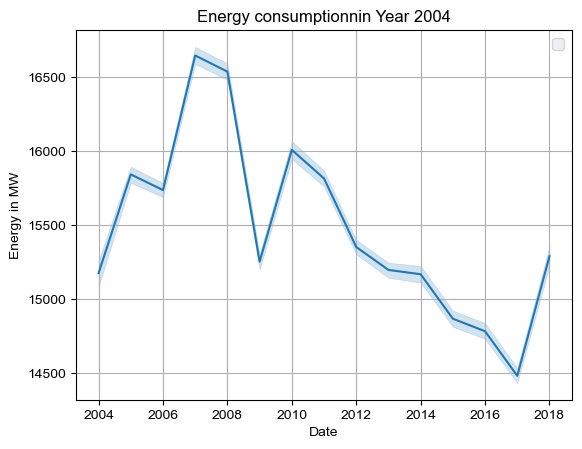

In [4]:
from matplotlib import style
fig = plt.figure()
ax1 = plt.subplot2grid((1, 1),(0, 0))

style.use('ggplot')

sns.lineplot(x=dataset["Year"], y=dataset["AEP_MW"], data=df) # generate a line plot of the year vs power usage
sns.set(rc={'figure.figsize':(15,6)})

plt.title("Energy consumptionnin Year 2004")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


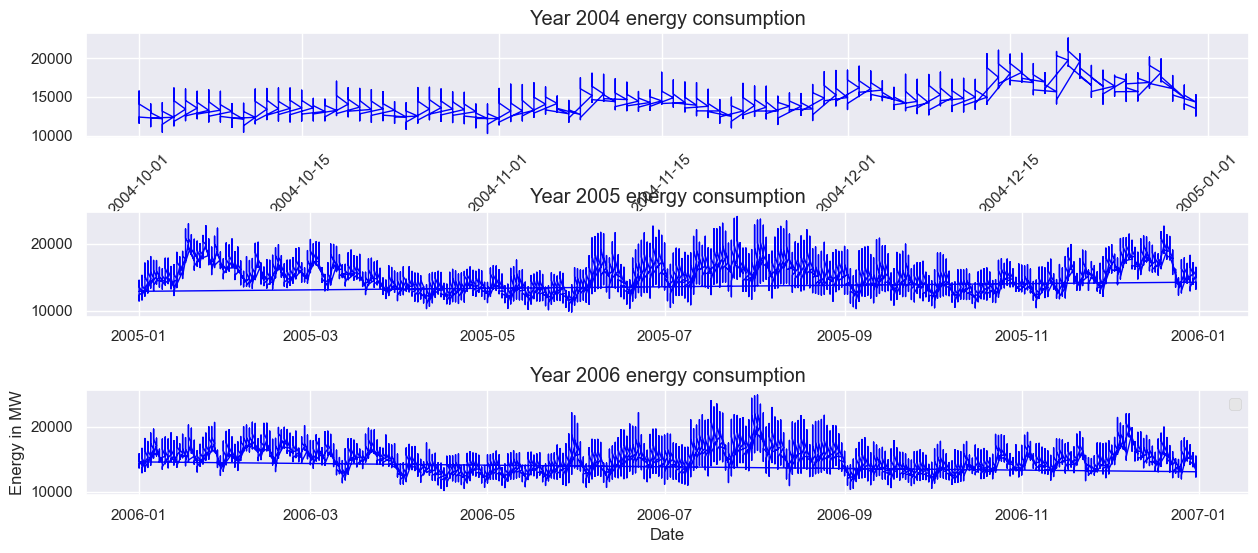

In [5]:
#plot the energy consumption for three years(2004-2006)

fig = plt.figure()
fig.subplots_adjust( hspace=0.7)
ax1= fig.add_subplot(311)
ax2= fig.add_subplot(312)
ax3= fig.add_subplot(313)

style.use('ggplot')
y_2004 = dataset[dataset["Year"] == 2004]["AEP_MW"].to_list()
x_2004 = dataset[dataset["Year"] == 2004]["Date"].to_list()

style.use('ggplot')
ax1.plot(x_2004, y_2004, color="blue", linewidth= 1)
ax1.set_title("Year 2004 energy consumption")


y_2005 = dataset[dataset["Year"] ==2005]["AEP_MW"].to_list()
x_2005 = dataset[dataset["Year"] ==2005]["Date"].to_list()

ax2.plot(x_2005, y_2005, color="blue", linewidth=1)
ax2.set_title("Year 2005 energy consumption")

y_2006 = dataset[dataset["Year"] ==2006]["AEP_MW"].to_list()
x_2006 = dataset[dataset["Year"] ==2006]["Date"].to_list()
ax3.plot(x_2006, y_2006, color="blue", linewidth=1)
ax3.set_title("Year 2006 energy consumption")

plt.rcParams["figure.figsize"] = (18,8)
# plt.title("Energy consumption")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True, alpha=1)
plt.legend()


for label in ax1.xaxis.get_ticklabels():
    label.set_rotation(45)
    

Text(0.5, 1.0, 'energy distribution')

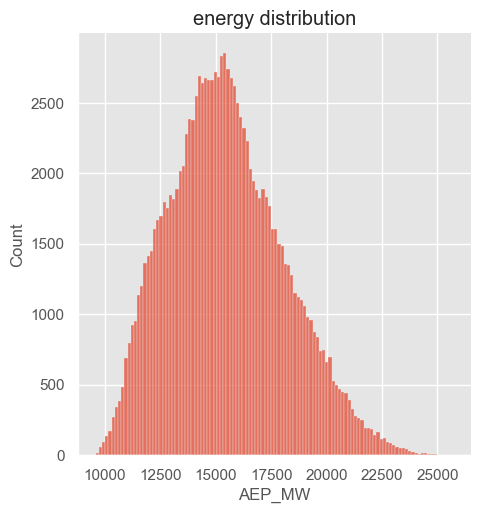

In [6]:
sns.displot(dataset["AEP_MW"]) #disribution of the dataset suggests a normal distribution
plt.title("energy distribution")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


,AEP_MW,Month,Year,Date,Time,Week,hr
Datetime,,,,,,,
2004-12-31 01:00:00,13478.0,12,2004,2004-12-31,01:00:00,53,1
2004-12-31 02:00:00,12865.0,12,2004,2004-12-31,02:00:00,53,2
2004-12-31 03:00:00,12577.0,12,2004,2004-12-31,03:00:00,53,3
2004-12-31 04:00:00,12517.0,12,2004,2004-12-31,04:00:00,53,4
2004-12-31 05:00:00,12670.0,12,2004,2004-12-31,05:00:00,53,5


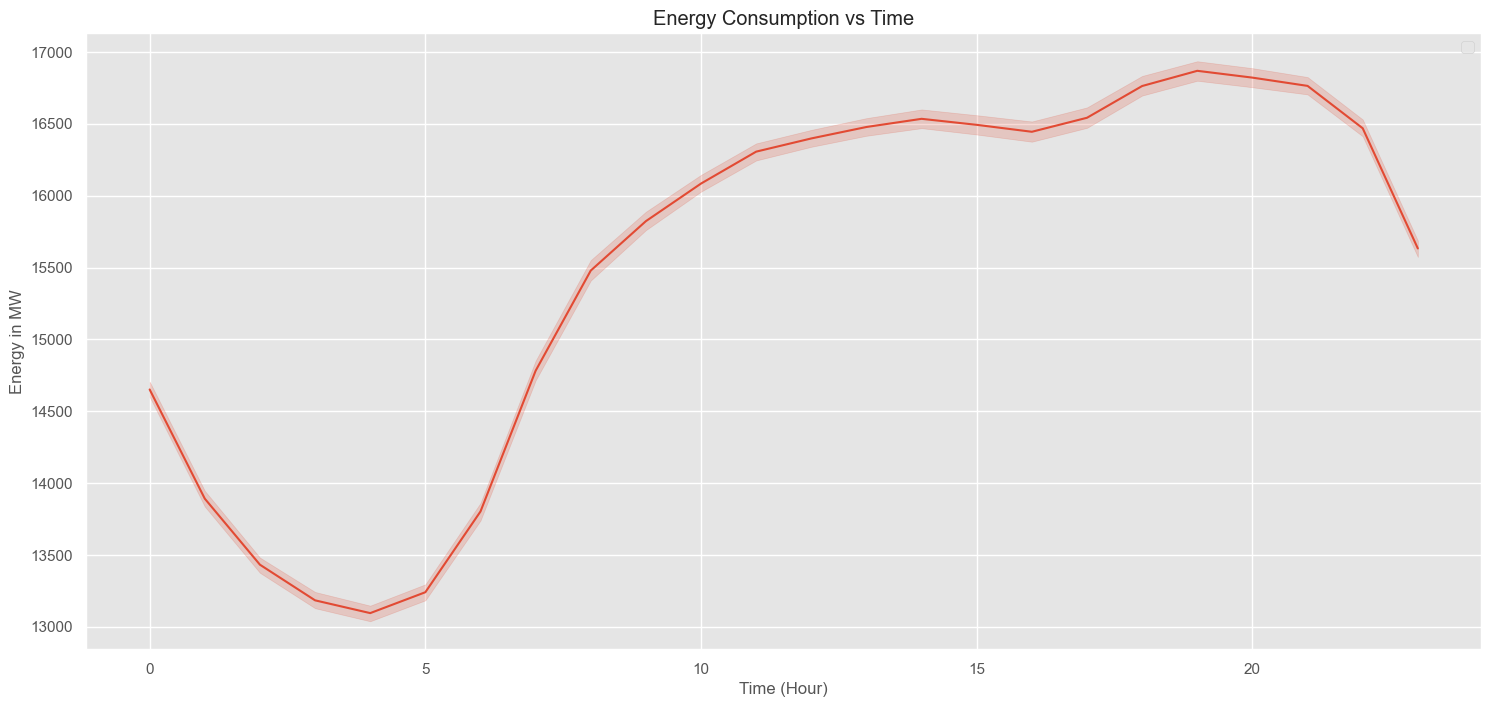

In [7]:
# Convert the "Time" column to just the hour component
dataset["hr"] = dataset["Time"].apply(lambda x: x.hour)

# Plot the line graph
sns.lineplot(x=dataset["hr"], y=dataset["AEP_MW"], data=dataset)

plt.title("Energy Consumption vs Time")
plt.xlabel("Time (Hour)")
plt.ylabel("Energy in MW")
plt.grid(True)
plt.legend()
dataset.head()


In [8]:
daily_energy = dataset.groupby("Date")["AEP_MW"].mean() #average energy per day
daily_energy.head()

Date
2004-10-01    14284.521739
2004-10-02    12999.875000
2004-10-03    12227.083333
2004-10-04    14309.041667
2004-10-05    14439.708333
Name: AEP_MW, dtype: float64

In [9]:
testData = np.array(daily_energy.tail(100)).reshape(-1,1) #select the last 100 rows of AEP_Mw column, convert it to numpy array and reshape it
trainingData = daily_energy.iloc[0:len(daily_energy)-100] #select remaining rows of AEP_Mw column as training data
print(len(trainingData), len(testData), len(trainingData)+len(testData), daily_energy.size) #check the sliced training and test data make up the original df

trainingSet = np.array(trainingData).reshape(-1,1) # convert trainingSet from df to np array



4955 100 5055 5055


In [10]:
sc = MinMaxScaler(feature_range = (0, 1)) # apply the min-max scaler to normalize the training data
Train = sc.fit_transform(trainingSet)
Train.shape

(4955, 1)

In [11]:
# modify the training set to a structure that suits the lstm model: 60 datapoints are used to predict the 61st value 
x_train = []
y_train = []

for i in range(60, len(Train)):
    x_train.append(Train[i-60:i])
    y_train.append(Train[i])

x_train, y_train = np.array(x_train), np.array(y_train) #convert the list into np array
print(x_train.shape, y_train.shape) #check the shapes, we need (#, 60, 1)

# Shape should be Number of [Datapoints , Steps , 1 )
# we convert into 3-d Vector or #rd Dimesnsion
x_train = np.reshape(x_train, newshape=(x_train.shape[0], x_train.shape[1], 1))


(4895, 60, 1) (4895, 1)


In [12]:
#  4 hidden layers each with 50 neurons and a dropout regularisation to avoid overfitting
regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (x_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error') #use the adam optimizer and the mean squared error for the loss


In [13]:
regressor.fit(x_train, y_train, epochs = 20, batch_size = 32)

Epoch 1/20
153/153 [==============================] - 61s 217ms/step - loss: 0.0218
Epoch 2/20
153/153 [==============================] - 21s 139ms/step - loss: 0.0181
Epoch 3/20
153/153 [==============================] - 22s 146ms/step - loss: 0.0170
Epoch 4/20
153/153 [==============================] - 20s 130ms/step - loss: 0.0164
Epoch 5/20
153/153 [==============================] - 20s 129ms/step - loss: 0.0159
Epoch 6/20
153/153 [==============================] - 19s 122ms/step - loss: 0.0152
Epoch 7/20
153/153 [==============================] - 18s 120ms/step - loss: 0.0151
Epoch 8/20
153/153 [==============================] - 29s 191ms/step - loss: 0.0139
Epoch 9/20
153/153 [==============================] - 23s 153ms/step - loss: 0.0119
Epoch 10/20
153/153 [==============================] - 26s 171ms/step - loss: 0.0100
Epoch 11/20
153/153 [==============================] - 23s 148ms/step - loss: 0.0089
Epoch 12/20
153/153 [==============================] - 20s 129ms/step - lo

In [ ]:
inputs = sc.transform(testData) # normalize the test data

#arrange the test data to a structure as required by the lstm model
x_test = [] 

for i in range(60, len(testData)):
    x_test.append(inputs[i-60:i])

x_test = np.array(x_test) #convert to array
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1)) #reshape to (#, 60, ))

predicted_load = regressor.predict(x_test) #use the test data to predict the load via the model developed
predicted_load = sc.inverse_transform(predicted_load) #inverse transform the output for clear comparison with actual load data


2/2 [==============================] - 0s 18ms/step


In [ ]:
dates = daily_energy.tail(100)[60::].index # store the dates(index) of the test data 

comparison_df = pd.DataFrame(data = {
    "Data": dates, # first column 
    "True value": daily_energy.tail(100)[60::].values, # second column: True value from original data
    "Predicted value": [x[0] for x in predicted_load ] # predicted value from the lstm model
}) #create a df of predictions and actual values

comparison_df.set_index("Data") 

40


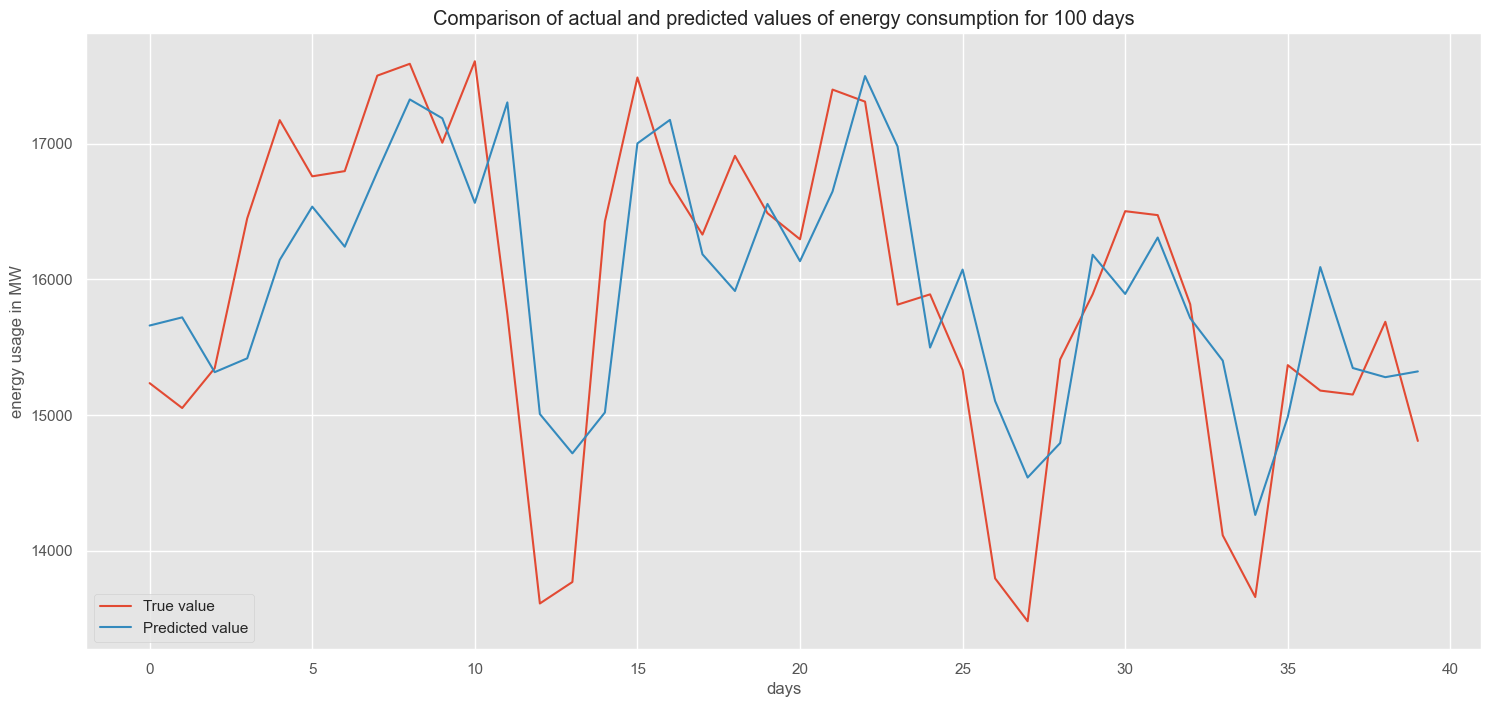

In [16]:
fig = plt.figure() #visualization of the accuracy of the plot
ax1 = fig.add_subplot(111)

ax1.plot(comparison_df.index, comparison_df["True value"], label="True value")
ax1.plot(comparison_df.index, comparison_df["Predicted value"], label="Predicted value")

plt.xlabel("days")
plt.ylabel("energy usage in MW")
plt.title("Comparison of actual and predicted values of energy consumption for 100 days")
plt.legend(loc="lower left")
plt.show()

,Actual value Vs LSTM model prediction
Root mean squared error,765.316652
Mean absolute error,637.444621


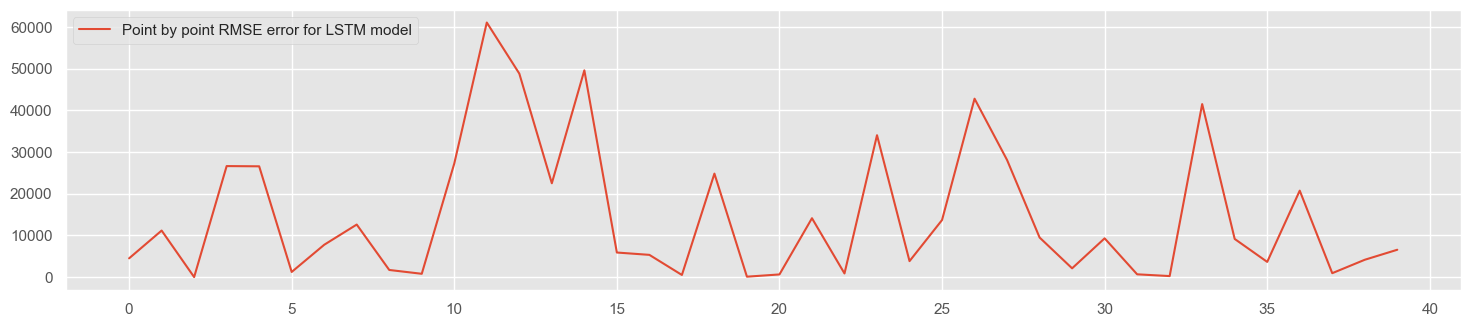

In [24]:
def error_comparison(yr, y2):

       x_points = [i for i in range(len(yr))]
       error_1 = [(i[0]-i[1])**2/len(yr) for i in list(zip(yr, y2))]
      
       fig = plt.figure()

       ax1 = fig.add_subplot(211)

       ax1.plot(x_points, error_1, label="Point by point RMSE error for LSTM model")

       ax1.legend(loc="upper left")

       table_error = {"Actual value Vs LSTM model prediction": [math.sqrt(mean_squared_error(yr,y2)), mean_absolute_error(yr,y2)],
              }
       
       error_df = pd.DataFrame(table_error, index = ["Root mean squared error", "Mean absolute error"])
       return error_df
       
error_comparison(comparison_df["True value"].to_list(), comparison_df["Predicted value"].to_list())